In [1]:
#!pip install --q sentence-transformers
#!pip install --q deep-translator

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from deep_translator import GoogleTranslator
import openpyxl
import numpy as np

translator = GoogleTranslator(source="auto", target="en")

pd.reset_option('display')


In [3]:
combined_df = pd.read_csv('FINAL_REDDIT_DATA_TRANSLATED.csv')

In [20]:
combined_df['Source Subreddit'].value_counts(normalize=True)

Source Subreddit
r/phcareers         0.550622
r/freelance         0.117229
r/OFWs              0.067496
r/jobs              0.062167
r/recruitinghell    0.062167
r/jobsearchhacks    0.062167
r/Philippines       0.051510
r/careerguidance    0.026643
Name: proportion, dtype: float64

In [4]:
combined_df['Platform Mentioned'].str.split(',').explode().str.strip().value_counts(normalize=True)

Platform Mentioned
LinkedIn                     0.461538
Indeed                       0.174825
Jobstreet                    0.104895
Reddit                       0.069930
Glassdoor                    0.027972
Kalibrr                      0.027972
Upwork                       0.020979
Instagram                    0.020979
WorkAbroad.ph                0.020979
Facebook                     0.013986
Twine                        0.013986
Meta                         0.006993
Proxify                      0.006993
Contra                       0.006993
Seek                         0.006993
Jobseek                      0.006993
MyCareersFuture Singapore    0.006993
Name: proportion, dtype: float64

# Converting the Content to English

In [5]:
def translate_to_english(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return text
        return translator.translate(str(text))
    except Exception:
        return text

In [6]:
# combined_df["Content (English)"] = combined_df["Content (Full Text)"].apply(translate_to_english)
# combined_df.to_csv('FINAL_REDDIT_DATA_TRANSLATED.csv', index=False)


# # of K

In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [8]:
def evaluate_k(df, job_platform, k_range=range(2, 9), model=model):
    # --- filter rows by job platform mention (comma-separated column) ---
    subset = df[df["Platform Mentioned"].str.contains(job_platform, na=False)].copy()

    print(subset.shape)
    texts = subset["Content (English)"].fillna("").tolist()

    if len(texts) < 10:
        print(f"Not enough data for {job_platform}")
        return

    # --- embeddings ---
    embeddings = model.encode(texts, show_progress_bar=False)
    embeddings = normalize(embeddings)

    results = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(embeddings)

        if len(np.unique(labels)) < 2:
            continue

        results.append({
            "k": k,
            "silhouette": silhouette_score(embeddings, labels),
            "davies_bouldin": davies_bouldin_score(embeddings, labels),
            "calinski_harabasz": calinski_harabasz_score(embeddings, labels),
            "inertia": kmeans.inertia_
        })

    results_df = pd.DataFrame(results)

    print(f"\n===== {job_platform} =====")
    print(results_df)

    # --- plotting ---
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{job_platform} - Clustering Evaluation Metrics")

    axs[0, 0].plot(results_df["k"], results_df["inertia"], marker="o")
    axs[0, 0].set_title("Inertia (Elbow)")
    axs[0, 0].set_xlabel("k")

    axs[0, 1].plot(results_df["k"], results_df["silhouette"], marker="o")
    axs[0, 1].set_title("Silhouette Score (higher is better)")
    axs[0, 1].set_xlabel("k")

    axs[1, 0].plot(results_df["k"], results_df["davies_bouldin"], marker="o")
    axs[1, 0].set_title("Davies-Bouldin (lower is better)")
    axs[1, 0].set_xlabel("k")

    axs[1, 1].plot(results_df["k"], results_df["calinski_harabasz"], marker="o")
    axs[1, 1].set_title("Calinski-Harabasz (higher is better)")
    axs[1, 1].set_xlabel("k")

    plt.tight_layout()
    plt.show()

    return results_df

In [9]:
def show_cluster_platform(df, job_platform, k=2):
    # --- filter by job platform (comma-separated column) ---
    subset = df[df["Platform Mentioned"].str.contains(job_platform, na=False)].copy()
    texts = subset["Content (English)"].fillna("").tolist()

    # --- safety check ---
    if len(texts) < 10:
        print(f"Not enough data for {job_platform}")
        return

    # --- embeddings ---
    embeddings = model.encode(texts, show_progress_bar=False)
    embeddings = normalize(embeddings)

    # --- clustering ---
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)

    subset["Sub_theme"] = labels

    print(f"\n===== {job_platform} =====")

    # --- print all content per cluster ---
    for i in range(k):
        print(f"\n===== Sub-theme {i} =====\n")

        cluster_df = subset[subset["Sub_theme"] == i]

        display(
            cluster_df[
                ["Content (Full Text)", "Upvotes / Score", "Sub_theme"]
            ].reset_index(drop=True)
        )

    return subset

In [10]:
def print_notable_quotes(df, cluster_col="Sub_theme",
                         cols=["Content (English)", "Upvotes / Score"],
                         max_per_cluster=None):
    
    clusters = sorted(df[cluster_col].dropna().unique())

    for c in clusters:
        print(f"\n===== Sub-cluster {c} =====\n")

        cluster_texts = (
            df[df[cluster_col] == c][cols]
            .fillna("")
            .to_dict(orient="records")   # 🔥 key fix
        )

        for i, text in enumerate(cluster_texts, 1):
            if max_per_cluster is not None and i > max_per_cluster:
                break

            print(f"{i} - Upvote {text['Upvotes / Score']}. {text['Content (English)']}\n")

# LinkedIn

(66, 15)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



===== LinkedIn =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.047470        3.826414           4.315194  40.712318
1  3    0.037701        3.566663           3.784472  38.796280
2  4    0.050364        2.915319           4.061938  36.319008
3  5    0.037183        3.027594           3.101868  36.112099
4  6    0.038123        2.855945           3.023322  34.711899
5  7    0.027352        2.695383           2.752580  33.953079
6  8    0.021511        2.542026           2.693750  32.795326


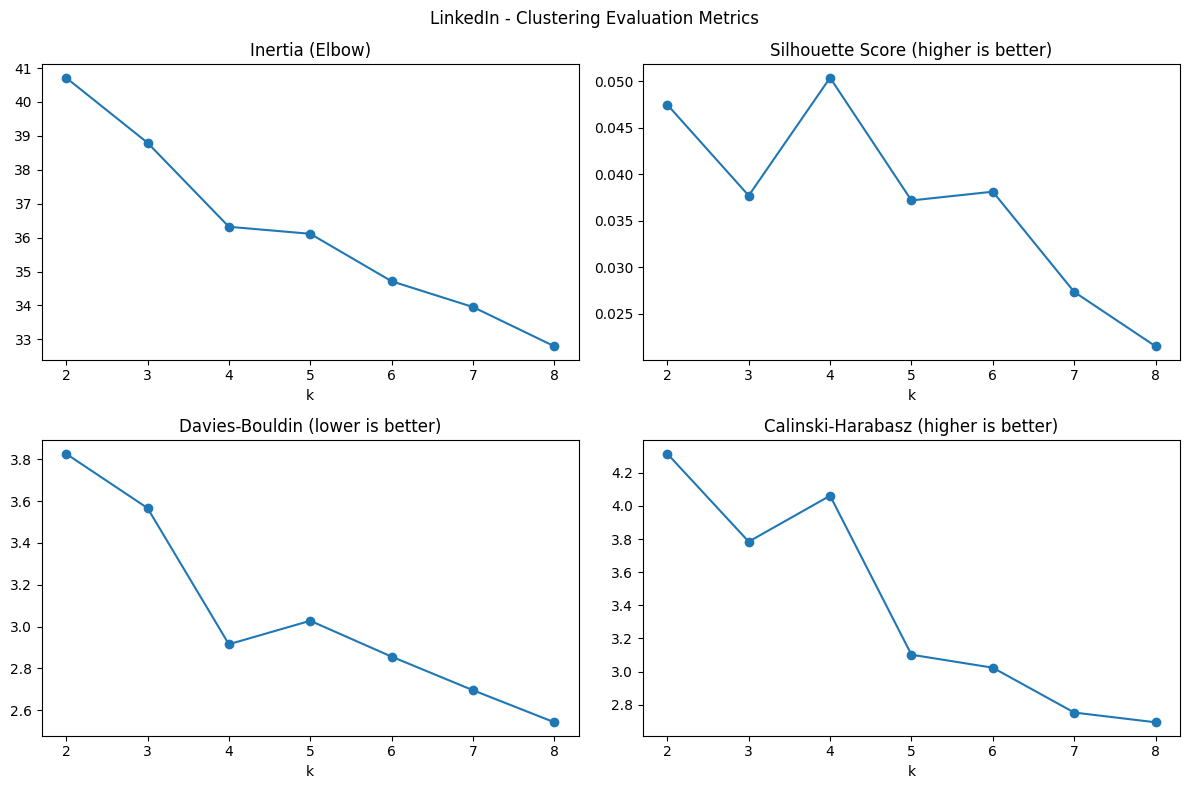

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.047470,3.826414,4.315194,40.712318
1,3,0.037701,3.566663,3.784472,38.796280
2,4,0.050364,2.915319,4.061938,36.319008
3,5,0.037183,3.027594,3.101868,36.112099
4,6,0.038123,2.855945,3.023322,34.711899
5,7,0.027352,2.695383,2.752580,33.953079
6,8,0.021511,2.542026,2.693750,32.795326


In [11]:
evaluate_k(combined_df, "LinkedIn")

In [12]:
subset = show_cluster_platform(combined_df, "LinkedIn", k=4)

print_notable_quotes(subset)


===== LinkedIn =====

===== Sub-theme 0 =====



,Content (Full Text),Upvotes / Score,Sub_theme
0,JOB SEEKERS. FRIENDS. COLLEAGUES.\n\nI've been...,1693,0
1,**TL/DR:** I've been out of work for over a ye...,735,0
2,The job market is trash. I know very qualified...,614,0
3,I don’t even know how to start this post. I’m ...,507,0
4,Hey everyone. I have been unemployed since Apr...,391,0
5,The struggle is real and crushing. On the othe...,1949,0
6,I know this is long but I wish someone had pos...,2511,0
7,"Laid off on April 4 from a fully remote, IT Di...",1927,0
8,"After a few months of unemployment, I can fina...",525,0
9,I’m writing this with complete exhaustion and ...,227,0



===== Sub-theme 1 =====



,Content (Full Text),Upvotes / Score,Sub_theme
0,I got hired by a startup in the US as a foundi...,1707,1
1,I just spent my entire Sunday filming Instagra...,100,1
2,This is the part of freelancing nobody warned ...,23,1
3,"For me at least, as a designer I am making con...",1,1
4,"I get most of my clients from here, LinkedIn, ...",7,1
5,I used to attend my niche conferences (web3.0)...,2,1
6,[.](https://preview.redd.it/oubmptlfg1zf1.png?...,36,1
7,"Hey all,\n\nI'm a graphic designer with a norm...",29,1
8,"I’m a sole proprietorship, and most of my clie...",7,1
9,"Hey everyone,\n\nI’ve noticed something intere...",22,1



===== Sub-theme 2 =====



,Content (Full Text),Upvotes / Score,Sub_theme
0,Currently 3rd yr Mech Eng ako from not so pres...,98,2
1,i did resign without a new job last year. one ...,1,2
2,"Listen, someone out there will bite an 18k sal...",147,2
3,Here is my untested and unproven golden formul...,98,2
4,Madami akong nababasa dito about difficulty of...,1263,2
5,*My POV comes from \~5 years of experience acr...,155,2
6,Hi everyone! \n\nCan you help me build a check...,143,2
7,"Hi everyone,\n\nI'm hoping to get some guidanc...",89,2
8,"Hi, I’m currently in my job-hunt era.\n\nI was...",27,2
9,I have this irrational fear that I’ll eventual...,18,2



===== Sub-theme 3 =====



,Content (Full Text),Upvotes / Score,Sub_theme
0,"I feel the same frustrations as you, OP. I’ve ...",51,3
1,got lay off i'm an OFW. i've sent almost 2000 ...,5,3
2,Kung sa linkedin ka nag apply check mo kung po...,1,3
3,Hi OP. I highly suggest that you explore clien...,1,3
4,"Hello! In average, or based sa experience niny...",89,3
5,"(Not sure if it's the right flair, I'm sorry)\...",11,3
6,What's your honest take on organizations who d...,7,3
7,Out of the job searches I've had in more than ...,3,3
8,Posted through my linkedin profile that I'm op...,2,3
9,No one literally no one is hiring me! Is this ...,2266,3



===== Sub-cluster 0 =====

1 - Upvote 1693. JOB SEEKERS. FRIENDS. COLLEAGUES.

I've been job hunting since December. Months grinding. Hundreds of applications, a few interviews, constant ghosting... you get it. Was literally asking my buddy last week if he knew anyone hiring at warehouses because I was getting desperate.

Then a family friend out of the blue mentions he knows someone who might be able to help. I'm thinking great, another dead end, but whatever worth trying. Get the intro and suddenly i'm on a call with the CEO of some boutique marketing agency in NYC.

The CEO almost bailed. But we ended up talking for an hour instead of 15 minutes. I showed her some projects I'd been working on and she straight up called me a "crazy genius". Which im not... lol.  I'm ADHD as hell, I've just learned to replace raw IQ with pure grit.

Now we're doing this 90-day trial together, she's pumped about it and is hoping I stay on full time at the end. I'm still processing tbh.

The best? She 

# indeed

(25, 15)

===== Indeed =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.050955        3.133716           2.315124  14.574951
1  3    0.049152        2.682333           2.223173  13.344931
2  4    0.034799        2.369929           1.918049  12.591788
3  5    0.043283        2.152767           1.997604  11.462515
4  6    0.034768        2.022400           1.834442  10.819122
5  7    0.029862        1.797719           1.759654  10.111258
6  8    0.030061        1.535705           1.767618   9.284427


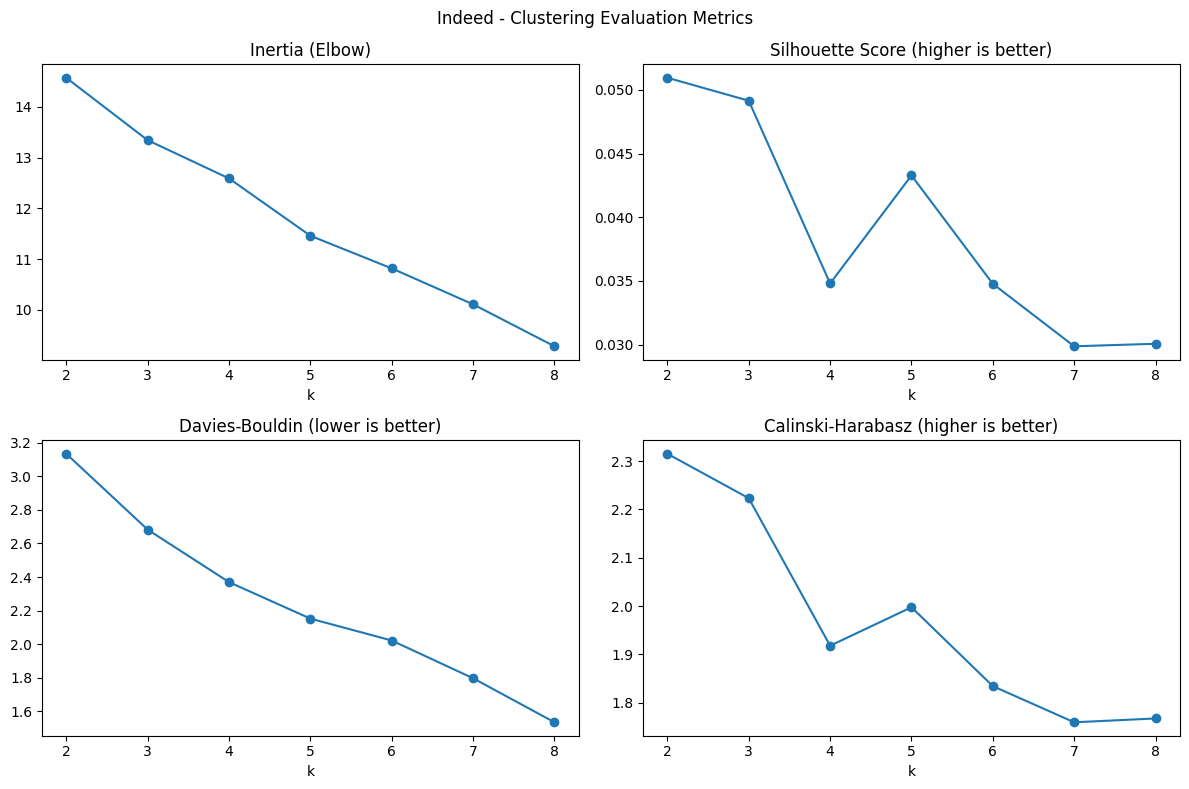

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.050955,3.133716,2.315124,14.574951
1,3,0.049152,2.682333,2.223173,13.344931
2,4,0.034799,2.369929,1.918049,12.591788
3,5,0.043283,2.152767,1.997604,11.462515
4,6,0.034768,2.022400,1.834442,10.819122
5,7,0.029862,1.797719,1.759654,10.111258
6,8,0.030061,1.535705,1.767618,9.284427


In [13]:
evaluate_k(combined_df, "Indeed")

In [14]:

subset = show_cluster_platform(df, "Indeed", k=5)

print_notable_quotes(subset)

NameError: name 'df' is not defined

# Jobstreet

(15, 15)

===== Jobstreet =====
   k  silhouette  davies_bouldin  calinski_harabasz   inertia
0  2    0.066042        2.509640           1.802336  7.485169
1  3    0.060148        1.934164           1.561028  6.763305
2  4    0.064283        1.547575           1.671276  5.854449
3  5    0.072370        1.214175           1.792870  4.963418
4  6    0.051874        1.425156           1.780798  4.284312
5  7    0.063537        1.181873           1.929471  3.482861
6  8    0.064286        1.009645           1.923458  2.915357


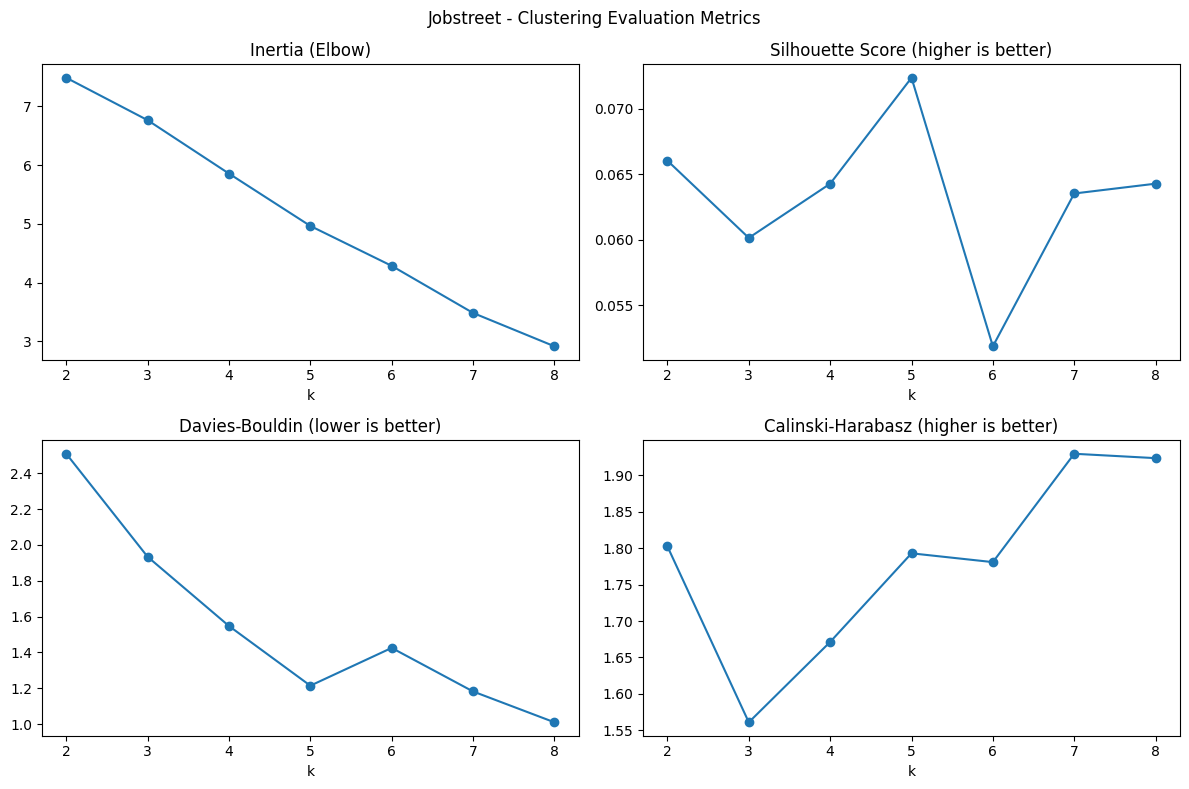

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.066042,2.509640,1.802336,7.485169
1,3,0.060148,1.934164,1.561028,6.763305
2,4,0.064283,1.547575,1.671276,5.854449
3,5,0.072370,1.214175,1.792870,4.963418
4,6,0.051874,1.425156,1.780798,4.284312
5,7,0.063537,1.181873,1.929471,3.482861
6,8,0.064286,1.009645,1.923458,2.915357


In [ ]:
evaluate_k(combined_df, "Jobstreet")

In [ ]:

subset = show_cluster_platform(combined_df, "Jobstreet", k=5)

print_notable_quotes(subset)


===== Jobstreet =====

===== Sub-theme 0 =====



,Content (Full Text),Upvotes / Score,Sub_theme
0,I have been actively looking for work for the ...,71,0
1,i did resign without a new job last year. one ...,1,0
2,I did this thrice in span of 4 years. I don't ...,1,0
3,got lay off i'm an OFW. i've sent almost 2000 ...,5,0
4,"Hi Op, \n\n\nI hope you are doing well. May ...",3,0
5,"Been applying for jobs ever since I (F, 24) wa...",227,0
6,Hello guys just wanted to share na after 4 mon...,144,0
7,"Hi everyone,\n\nI'm hoping to get some guidanc...",89,0
8,Hello. I just graduated and I am looking for a...,2,0



===== Sub-theme 1 =====



,Content (Full Text),Upvotes / Score,Sub_theme
0,Hi OP. I highly suggest that you explore clien...,1,1
1,"Hello! In average, or based sa experience niny...",89,1



===== Sub-theme 2 =====



...


===== Sub-theme 3 =====



,Content (Full Text),Upvotes / Score,Sub_theme
0,Napansin ko lang na sobrang laki na ng impact ...,0,3



===== Sub-theme 4 =====



,Content (Full Text),Upvotes / Score,Sub_theme
0,"Hi, I am an Estimator/Quantity Surveyor with 3...",7,4



===== Sub-cluster 0 =====

1. I have been actively looking for work for the past 3 months and I never knew how difficult it would be. I graduated with a bachelors degree in business administration majoring in HRM last year at a local college. I took a break after graduation pero napasobra ata. 

While on break, I attended yung mga free webinars conducted by government agencies and universities. I took a certification for HR associate. I built my resume little by little pero I think napagiwanan na ako ng mga blockmates ko. Most of them are starting to work na kasi and I felt envious. 

Nagpunta na ako kung saan ako nag ojt hoping na hiring sila. They did let me take the pre-employment exam pero I never heard from them hanggang ngayon ,I'll just assume that I failed. I wrote to some agencies hoping to hear from them but nothing. I attended my first job fair, the first company na nilapitan ko they sound very impressed sa application ko. I was really hopeful at that time. But months have 